# Round 2 Manual - Deterministic Math vs Crowd Game

This notebook keeps both sides of Round 2. First, it solves the clean deterministic frontier for `Research`, `Scale`, and `Speed`. Then it shows why that clean frontier was not enough, because `Speed` was a ranking game against the field rather than a normal productive variable.

The main contrast is the tempting low-speed shape like `21 / 66 / 13` versus the crowd-aware submission we would defend: `15 / 43 / 42`.


In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

BUDGET = 50_000

def research(x):
    return 200_000 * math.log1p(x) / math.log(101)

def scale(y):
    return 7 * y / 100

def best_rs_for_speed(z):
    best = None
    for r in range(0, 101 - z):
        s = 100 - z - r
        gross = research(r) * scale(s)
        row = (gross, r, s, z)
        if best is None or row > best:
            best = row
    return best

frontier = [best_rs_for_speed(z) for z in range(101)]
for z in [0, 13, 36, 42, 50, 70]:
    gross, r, s, _ = frontier[z]
    print("speed=%2d -> research=%2d scale=%2d pre_speed_gross=%9.2f top_mult_pnl=%9.2f" % (z, r, s, gross, gross * 0.9 - BUDGET))


speed= 0 -> research=23 scale=77 pre_speed_gross=742329.92 top_mult_pnl=618096.93
speed=13 -> research=21 scale=66 pre_speed_gross=618862.11 top_mult_pnl=506975.90
speed=36 -> research=16 scale=48 pre_speed_gross=412539.47 top_mult_pnl=321285.52
speed=42 -> research=15 scale=43 pre_speed_gross=361658.68 top_mult_pnl=275492.82
speed=50 -> research=13 scale=37 pre_speed_gross=296207.15 top_mult_pnl=216586.44
speed=70 -> research= 9 scale=21 pre_speed_gross=146683.06 top_mult_pnl= 82014.76


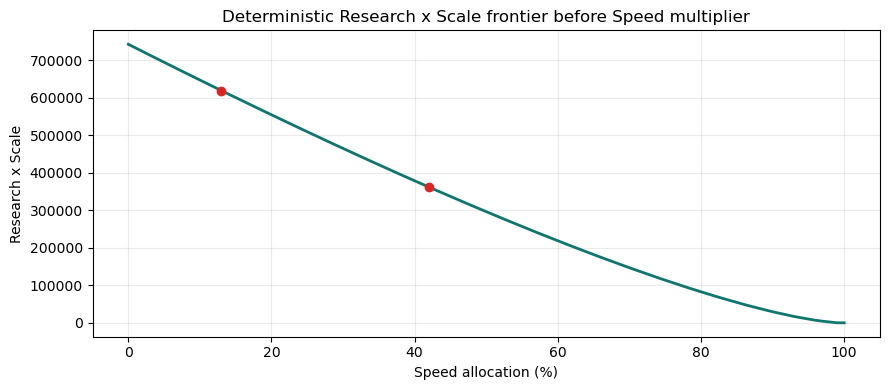

In [2]:
zs = np.arange(101)
gross = np.array([frontier[z][0] for z in zs])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(zs, gross, lw=2, color="#0f766e")
ax.scatter([13, 42], [frontier[13][0], frontier[42][0]], color="#dc2626", zorder=3)
ax.set_title("Deterministic Research x Scale frontier before Speed multiplier")
ax.set_xlabel("Speed allocation (%)")
ax.set_ylabel("Research x Scale")
ax.grid(alpha=0.25)
plt.tight_layout()


In [3]:
def logistic_mult(z, median, steepness):
    return 0.1 + 0.8 / (1 + math.exp(-(z - median) / steepness))

scenarios = [
    ("soft field", 12, 6),
    ("balanced field", 25, 8),
    ("speed war", 42, 7),
]
for label, med, steep in scenarios:
    best = None
    for z in range(101):
        gross, r, s, _ = frontier[z]
        m = logistic_mult(z, med, steep)
        pnl = gross * m - BUDGET
        row = (pnl, r, s, z, m)
        if best is None or row > best:
            best = row
    print("%-14s -> R=%2d S=%2d Speed=%2d mult=%.3f pnl=%9.2f" % (label, best[1], best[2], best[3], best[4], best[0]))

g13 = frontier[13][0]
g42 = frontier[42][0]
pnl42_top = g42 * 0.9 - BUDGET
threshold = (pnl42_top + BUDGET) / g13
print("\nSpeed 42 at top multiplier beats Speed 13 whenever multiplier_13 < %.3f" % threshold)
print("Speed 13 at m=0.5 -> %.2f" % (g13 * 0.5 - BUDGET))
print("Speed 42 at m=0.9 -> %.2f" % pnl42_top)


soft field     -> R=18 S=58 Speed=24 mult=0.805 pnl=366846.25
balanced field -> R=16 S=48 Speed=36 mult=0.739 pnl=254680.79
speed war      -> R=13 S=36 Speed=51 mult=0.727 pnl=159446.65

Speed 42 at top multiplier beats Speed 13 whenever multiplier_13 < 0.526
Speed 13 at m=0.5 -> 259431.06
Speed 42 at m=0.9 -> 275492.82


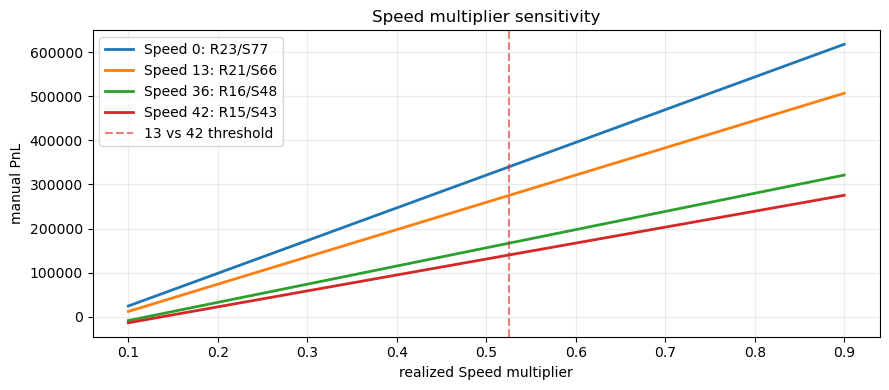

In [4]:
mults = np.linspace(0.1, 0.9, 81)
candidates = [0, 13, 36, 42]
fig, ax = plt.subplots(figsize=(9, 4))
for z in candidates:
    g, r, s, _ = frontier[z]
    ax.plot(mults, g * mults - BUDGET, label=f"Speed {z}: R{r}/S{s}", lw=2)
ax.axvline(threshold, color="#dc2626", ls="--", alpha=0.6, label="13 vs 42 threshold")
ax.set_title("Speed multiplier sensitivity")
ax.set_xlabel("realized Speed multiplier")
ax.set_ylabel("manual PnL")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
